# BridgeRNA drug-discovery benchmark

Executed audit notebook for the frozen Phase 2 outputs. Enrichment indicates target-set convergence only, not therapeutic efficacy.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
if ROOT.name!='drug_discovery': ROOT=ROOT/'benchmarks/drug_discovery'
EVAL=ROOT/'results/evaluation'

## Primary endpoint

,condition,bridge_mean_pairwise_top25_jaccard,de_mean_pairwise_top25_jaccard,bridge_minus_de,exact_p,permutations
0,Radiation,0.155354,0.041667,0.113688,0.250000,8
1,Bone loss,0.142308,0.180556,-0.038248,0.750000,8
2,Muscle atrophy,0.714286,0.182299,0.531987,0.250000,8
3,Overall,0.337316,0.134840,0.202475,0.058594,512


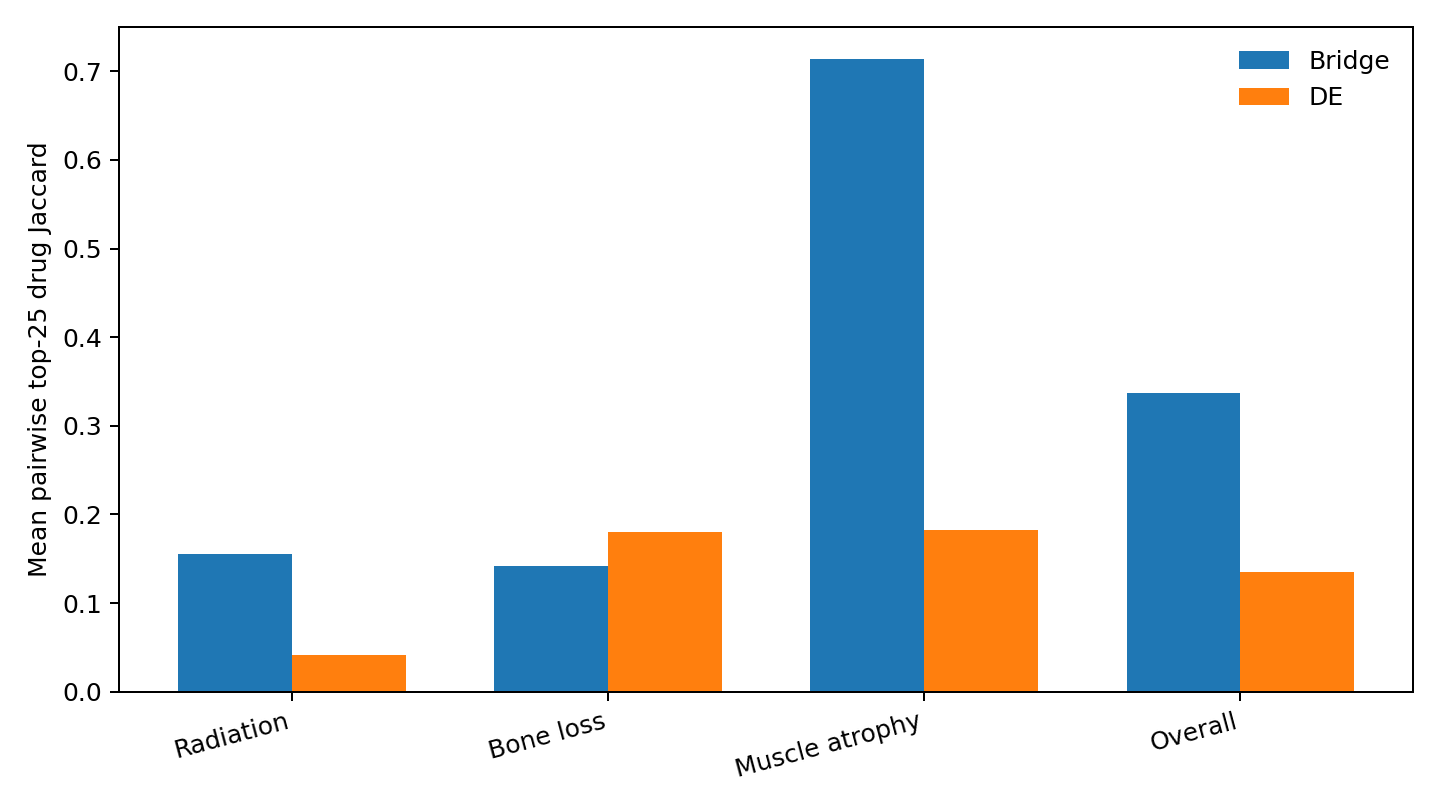

In [2]:
primary=pd.read_csv(EVAL/'primary_effects.csv')
display(primary)
display(Image(filename=ROOT/'results/figures/primary_drug_convergence.png'))

## Module-size sensitivity and random-module nulls

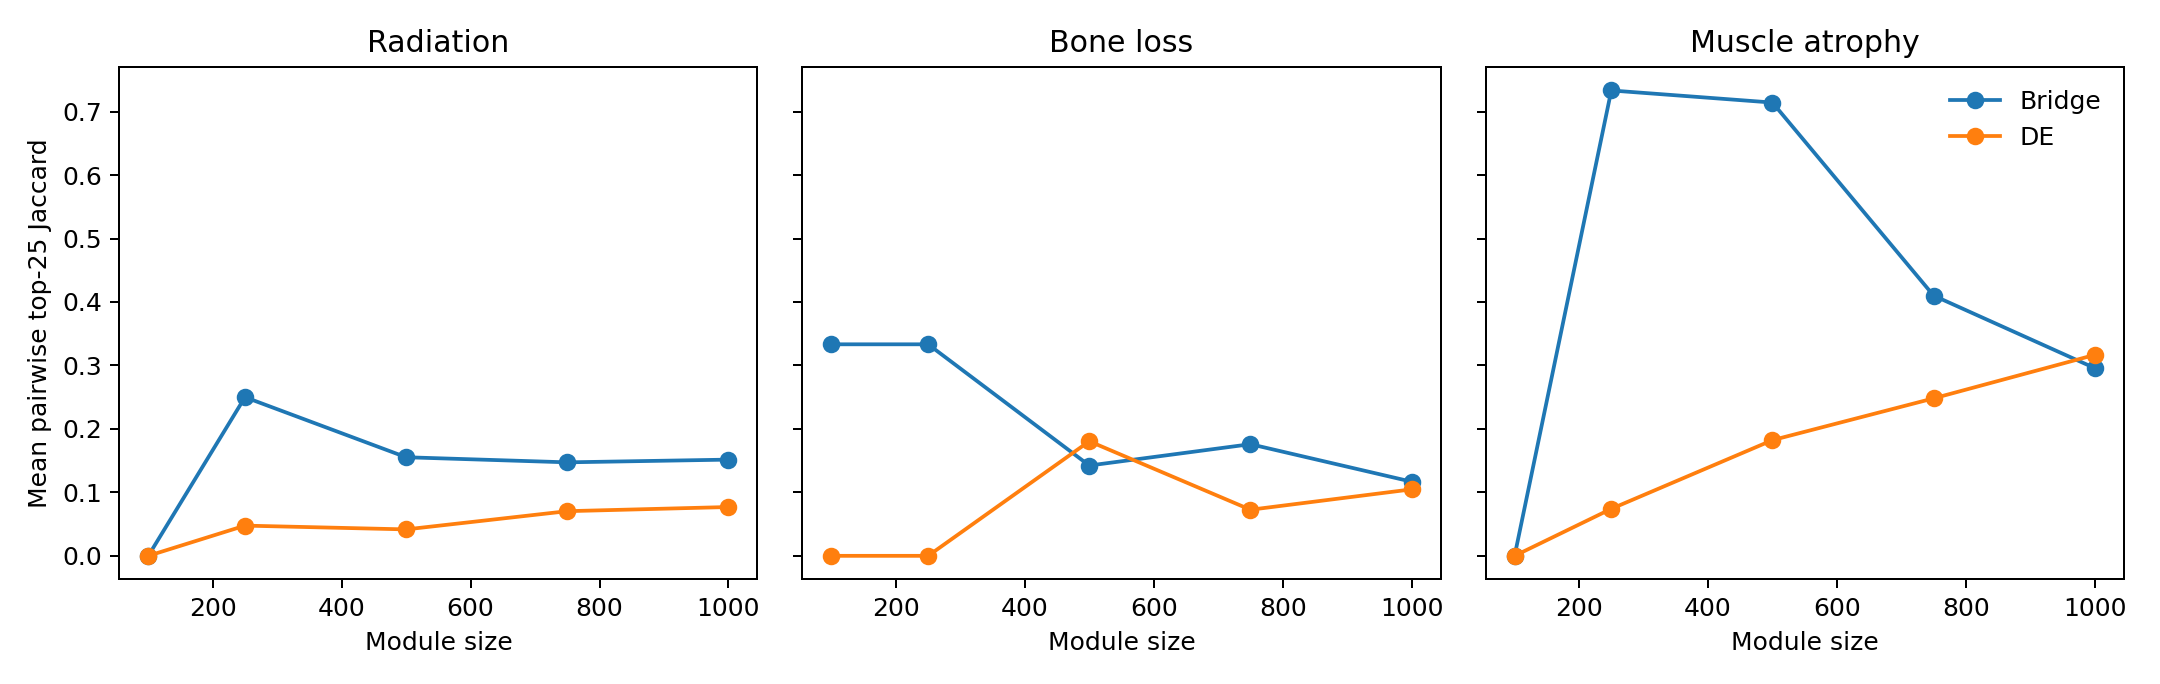

,condition,method,observed,random_mean,random_sd,empirical_p
0,Radiation,Bridge,0.155354,0.070885,0.081584,0.154845
1,Radiation,DE,0.041667,0.068569,0.083872,0.521479
2,Bone loss,Bridge,0.142308,0.080769,0.080255,0.190809
3,Bone loss,DE,0.180556,0.063488,0.070383,0.081918
4,Muscle atrophy,Bridge,0.714286,0.079110,0.105650,0.002997
5,Muscle atrophy,DE,0.182299,0.066039,0.075308,0.079920


In [3]:
display(Image(filename=ROOT/'results/figures/module_size_sensitivity.png'))
display(pd.read_csv(EVAL/'random_module_summary.csv'))

## ARCHS4 exposure and leakage sensitivity

In [4]:
display(pd.read_csv(EVAL/'pretraining_pair_effects.csv'))
display(pd.read_csv(EVAL/'pretraining_status_summary.csv'))
display(pd.read_csv(EVAL/'GSE211204_unseen_subject_convergence.csv'))

,condition,dataset_1,dataset_2,status_1,status_2,pretraining_pair,Bridge,DE,bridge_minus_de
0,Bone loss,GSE189524,GSE273868,unseen,unseen,strict_unseen_pair,0.250000,0.166667,0.083333
1,Bone loss,GSE189524,GSE276529,unseen,unseen,strict_unseen_pair,0.076923,0.375000,-0.298077
2,Bone loss,GSE276529,GSE273868,unseen,unseen,strict_unseen_pair,0.100000,0.000000,0.100000
3,Muscle atrophy,GSE113165,GSE234465,seen,unused-held-out,exposure_involved,0.571429,0.181818,0.389610
4,Muscle atrophy,GSE211204,GSE113165,partial,seen,exposure_involved,1.000000,0.222222,0.777778
5,Muscle atrophy,GSE211204,GSE234465,partial,unused-held-out,exposure_involved,0.571429,0.142857,0.428571
6,Radiation,GSE184119,GSE297560,seen,unseen,exposure_involved,0.076923,0.125000,-0.048077
7,Radiation,GSE297090,GSE184119,unseen,seen,exposure_involved,0.153846,0.000000,0.153846
8,Radiation,GSE297090,GSE297560,unseen,unseen,strict_unseen_pair,0.235294,0.000000,0.235294


,pretraining_pair,n_pairs,bridge_mean,de_mean,bridge_minus_de
0,exposure_involved,5,0.474725,0.134380,0.340346
1,strict_unseen_pair,4,0.165554,0.135417,0.030138


,method,mean_pairwise_top25_jaccard,pairwise_jaccards
0,Bridge,0.714286,1.0;0.5714285714285714;0.5714285714285714
1,DE,0.171717,0.2;0.13333333333333333;0.18181818181818182


## Attribution and deletion controls

In [5]:
display(pd.read_csv(ROOT/'results/bridge/ig_completeness.csv').describe(include='all'))
display(pd.read_csv(ROOT/'results/bridge/deletion_control_summary.csv'))

,contrast_id,sample_id,score_difference,attribution_sum,completeness_delta,absolute_completeness_delta
count,220,220,220.000000,220.000000,220.000000,220.000000
unique,16,200,NaN,NaN,NaN,NaN
top,GSE113165_bedrest,GSM8994796,NaN,NaN,NaN,NaN
freq,56,3,NaN,NaN,NaN,NaN
mean,NaN,NaN,-2.047670,-2.047868,-0.000199,0.002790
std,NaN,NaN,10.579958,10.582557,0.003346,0.001847
min,NaN,NaN,-17.737919,-17.741282,-0.011710,0.000021
25%,NaN,NaN,-13.425734,-13.427832,-0.002513,0.001308
50%,NaN,NaN,-1.827351,-1.826365,0.000163,0.002496
75%,NaN,NaN,7.156692,7.157606,0.002413,0.004143


,dataset,panel_type,mean_absolute_change,sd_absolute_change,mean_fraction_remaining
0,GSE113165,random,0.022419,0.011524,0.981940
1,GSE113165,top,0.105169,NaN,0.499457
2,GSE184119,random,0.006100,0.006921,0.957192
3,GSE184119,top,0.078377,NaN,0.447159
4,GSE189524,random,0.020571,0.007293,0.933109
5,GSE189524,top,0.106373,NaN,0.654113
6,GSE211204,random,0.017868,0.019182,1.023127
7,GSE211204,top,0.142545,NaN,0.815497
8,GSE234465,random,0.016586,0.008397,0.977490
9,GSE234465,top,0.211758,NaN,0.712596
